# Time Series Classification with Transformer

In [1]:
from pathlib import Path
from typing import Sequence, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 1 Load dataset

#### 1.1 Load data

In [2]:
# URLs
url_root_remote = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"
url_root_local = Path(".")

url_train_remote = url_root_remote + "FordA_TRAIN.tsv"
url_test_remote = url_root_remote + "FordA_TEST.tsv"

url_train_local = url_root_local / "FordA_TRAIN.tsv"
url_test_local = url_root_local / "FordA_TEST.tsv"

print(url_train_remote)
print(url_test_remote)
print(url_train_local)
print(url_test_local)

https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv
https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TEST.tsv
FordA_TRAIN.tsv
FordA_TEST.tsv


In [3]:
# Load and parse data
def load_data(url_remote: Union[Path, str], url_local: Union[Path, str]) -> (np.ndarray, np.ndarray):
    url_local = Path(url_local)
    if url_local.exists():
        data = np.load(url_local)
    else:
        data = np.loadtxt(url_remote, delimiter="\t")
        np.save(url_local, data)
    x = data[:, 1:]
    y = data[:, 0].astype(int)

    return x, y

x_train, y_train = load_data(url_train_remote, url_train_local)
x_test, y_test = load_data(url_test_remote, url_test_local)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3601, 500)
(1320, 500)
(3601,)
(1320,)


In [4]:
# Add channel
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

In [5]:
# Sort data
ids_random = np.random.permutation(len(x_train))
x_train = x_train[ids_random]
y_train = y_train[ids_random]

y_train[y_train == -1] = 0
y_test[y_test == -1] = 0

#### 1.2 Visualize data

In [6]:
x_train[y_train==0][:3].shape

(3, 500, 1)

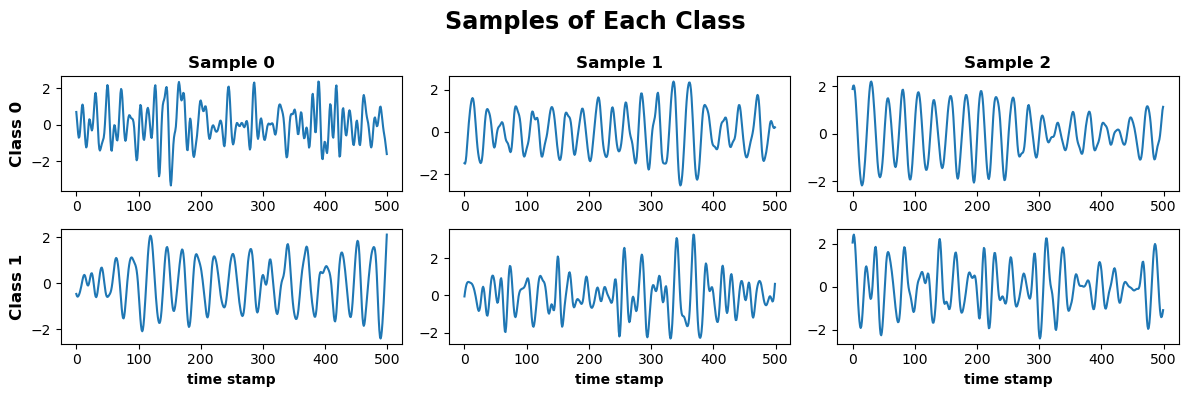

In [7]:
n_rows = 2
n_cols = 3

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, squeeze=False, figsize=(12, 4))

for i_row, axs_row in enumerate(axs):
    for ax, ts in zip(axs_row, x_train[y_train == i_row][:n_cols]):
        ax.plot(ts)
    axs_row[0].set_ylabel(f"Class {i_row}", fontsize="large", fontweight="bold")

for i_col, ax in enumerate(axs[0]):
    ax.set_title(f"Sample {i_col}", fontsize="large", fontweight="bold")

for ax in axs[-1]:
    ax.set_xlabel("time stamp", fontweight="bold")

# for ax in axs.T[0]:
#     ax.set_ylabel("value", fontweight="bold")

fig.suptitle("Samples of Each Class", fontsize="xx-large", fontweight="bold")
fig.tight_layout()

plt.show()

### 2 Build model

##### Transformer encoder block

In [8]:
def transformer_encoder(inputs: np.ndarray, head_size: int, num_heads: int, ff_dim: int, dropout: float = 0) -> tf.Tensor:
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)

    return x + res

##### Build model

In [9]:
def build_model(
    input_shape: Tuple[int, int],
    n_classes: int,
    head_size: int,
    num_heads: int,
    ff_dim: int,
    num_transformer_blocks: int,
    mlp_units: Sequence[int],
    dropout: float = 0,
    mlp_dropout: float = 0,
) -> keras.Model:
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

### 3 Train and evaluate

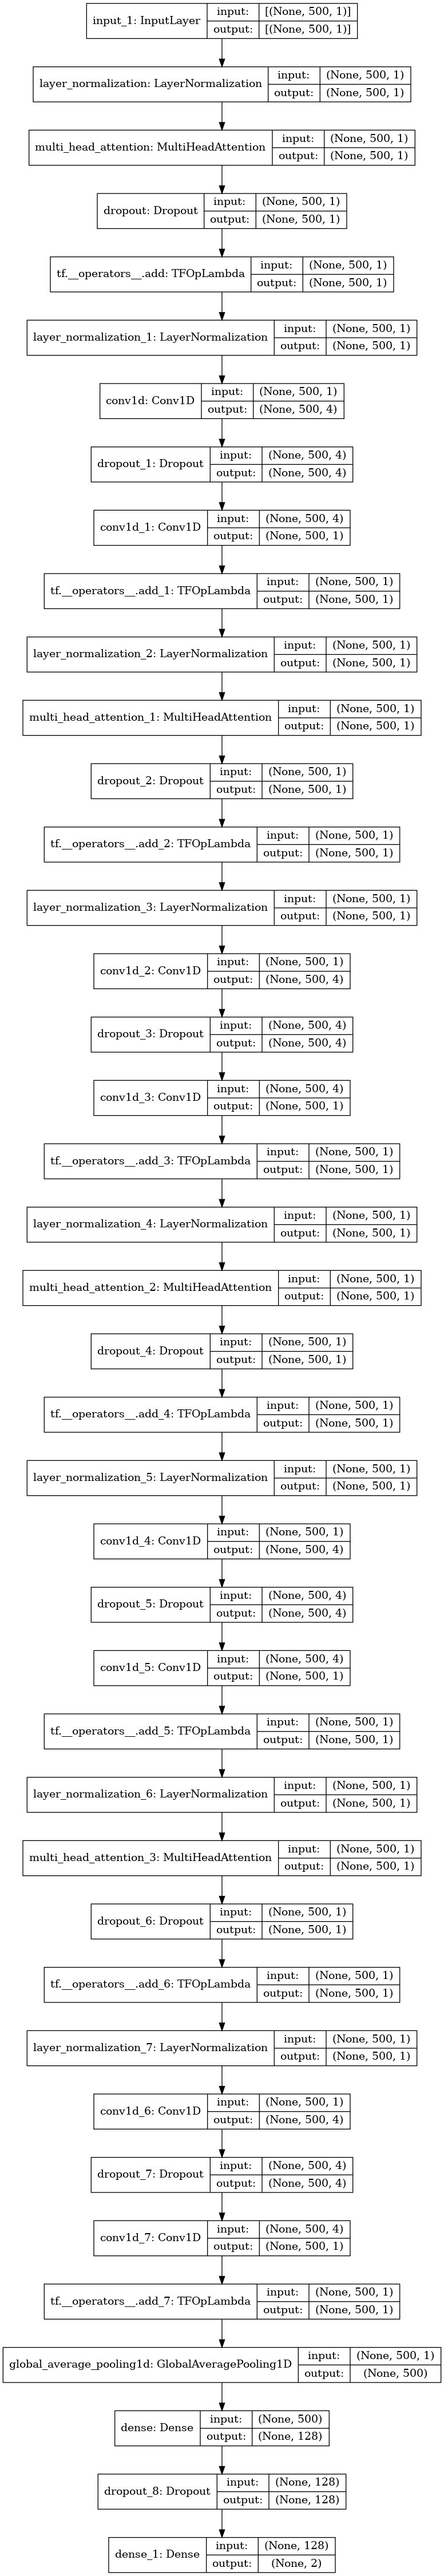

In [10]:
model = build_model(
    input_shape=x_train.shape[1:],
    n_classes=len(np.unique(y_train)),
    head_size=256,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=4,
    mlp_units=[128],
    mlp_dropout=0.4,
    dropout=0.25,
)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["sparse_categorical_accuracy"],
)

keras.utils.plot_model(model, show_shapes=True)

In [11]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 500, 1)]     0                                            
__________________________________________________________________________________________________
layer_normalization (LayerNorma (None, 500, 1)       2           input_1[0][0]                    
__________________________________________________________________________________________________
multi_head_attention (MultiHead (None, 500, 1)       7169        layer_normalization[0][0]        
                                                                 layer_normalization[0][0]        
__________________________________________________________________________________________________
dropout (Dropout)               (None, 500, 1)       0           multi_head_attention[0][0]   

In [14]:
callbacks = [keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]

model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
)

Epoch 1/200
180/180 [==============================] - 67s 355ms/step - loss: 0.9270 - sparse_categorical_accuracy: 0.5306 - val_loss: 0.6909 - val_sparse_categorical_accuracy: 0.5992
Epoch 2/200
180/180 [==============================] - 64s 355ms/step - loss: 0.7733 - sparse_categorical_accuracy: 0.6049 - val_loss: 0.6528 - val_sparse_categorical_accuracy: 0.6325
Epoch 3/200
180/180 [==============================] - 63s 349ms/step - loss: 0.7049 - sparse_categorical_accuracy: 0.6354 - val_loss: 0.6199 - val_sparse_categorical_accuracy: 0.6463
Epoch 4/200
180/180 [==============================] - 63s 348ms/step - loss: 0.6483 - sparse_categorical_accuracy: 0.6625 - val_loss: 0.6177 - val_sparse_categorical_accuracy: 0.6644
Epoch 5/200
180/180 [==============================] - 63s 350ms/step - loss: 0.5982 - sparse_categorical_accuracy: 0.6979 - val_loss: 0.5950 - val_sparse_categorical_accuracy: 0.6741
Epoch 6/200
180/180 [==============================] - 64s 353ms/step - loss: 0.

In [15]:
model.evaluate(x_test, y_test, verbose=1)

42/42 [==============================] - 9s 225ms/step - loss: 0.3759 - sparse_categorical_accuracy: 0.8371


[0.37587517499923706, 0.8371211886405945]